# Afrihealth Disease Surveillance - EDA

In [2]:
# Import libraries and initial setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# Load data

geo_types = {
    "urban_rural": "category"
}

fac_types = {
    "facility_type": "category",
    "facility_level": "category",
    "operation_status": "category",
    "established_year": "category"
}

reports_types = {
   "disease": "category",
   "age_group": "category",
   "gender": "category" 
}

geo = pd.read_csv('../data/raw/geographical.csv', dtype=geo_types)
fac = pd.read_csv('../data/raw/facilities.csv', dtype=fac_types)
weather = pd.read_csv('../data/raw/weather.csv')
reports = pd.read_csv('../data/raw/reports.csv', dtype=reports_types)

# Convert dates
weather['date'] = pd.to_datetime(weather['date'])
reports['report_date'] = pd.to_datetime(reports['report_date'])
reports['case_date'] = pd.to_datetime(reports['case_date'])

#### Data Quality Checks

In [4]:
# Scan datasets to check for quality issues.
def quality_check(df, name):
    # Check for missing values
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)

    if missing.sum() > 0:
        for col in missing[missing > 0].index:
            print(f"{col}: {missing[col]} missing values, making ({missing_pct[col]}%) in {name} dataset.")
    else:
        print(f'No missing values in {name} dataset')
    
    # Duplicates
    dup_count = df.duplicated().sum()
    if dup_count > 0:
        print(f'Duplicates: {dup_count} rows in {name} dataset.')
    else:
        print(f'No duplicates in {name} dataset')


quality_check(reports, "reports")
print()
quality_check(weather, "weather")
print()
quality_check(geo, "geographical")
print()
quality_check(fac, "facilities")
print()


cases: 18477 missing values, making (1.0%) in reports dataset.
deaths: 55314 missing values, making (3.0%) in reports dataset.
Duplicates: 9174 rows in reports dataset.

temperature_min_c: 5 missing values, making (0.0%) in weather dataset.
temperature_max_c: 5 missing values, making (0.0%) in weather dataset.
rainfall_mm: 2087 missing values, making (0.5%) in weather dataset.
humidity_pct: 5 missing values, making (0.0%) in weather dataset.
No duplicates in weather dataset

population: 4 missing values, making (1.75%) in geographical dataset.
No duplicates in geographical dataset

capacity: 6 missing values, making (0.94%) in facilities dataset.
No duplicates in facilities dataset



### Disease Overview

In [7]:
total_cases = reports['cases'].sum()
total_deaths = reports['deaths'].sum()

fatality_rate = (total_deaths / total_cases) * 100 if total_cases > 0 else 0

disease_summary = reports.groupby('disease').agg({
    "cases": "sum",
    "deaths": "sum",
    "recoveries": "sum"
}).round(0)

disease_summary['fatality_rate_pct'] = ((disease_summary['deaths'] / disease_summary['cases']) * 100).round(2)

reports_geo = reports.merge(geo[['geography_id', 'country_code', 'country_name']], how='left', on='geography_id')
country_summary = reports_geo.groupby('country_name').agg({
    "cases": "sum",
    "deaths": "sum",
    "recoveries": "sum"
})
country_summary['fatality_rate_pct'] = ((country_summary['deaths'] / country_summary['cases']) * 100).round(2)

#### Time Trends (Disease trends overtime)

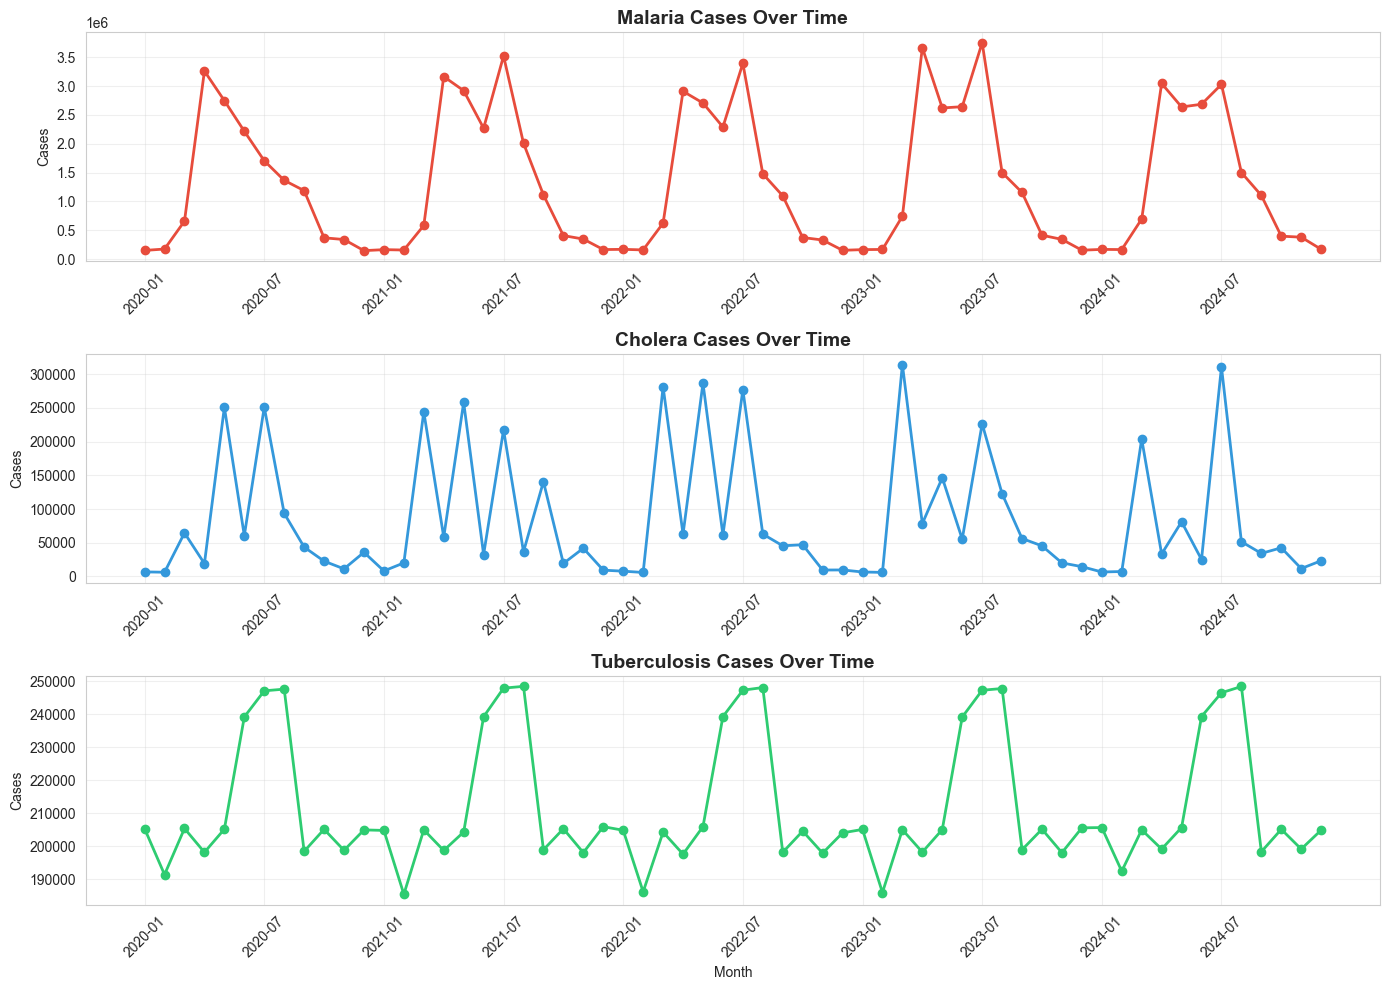

In [8]:
# Monthly aggregation
reports['year_month'] = reports['report_date'].dt.to_period('M')
monthly_cases = reports.groupby(['year_month', 'disease'])['cases'].sum().reset_index()
monthly_cases['year_month'] = monthly_cases['year_month'].astype('str')

# Visualize
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
diseases = ['Malaria', 'Cholera', 'Tuberculosis']
colors = ['#e74c3c', '#3498db', '#2ecc71']

for i, disease in enumerate(diseases):
    ax = axes[i]
    disease_data = monthly_cases[monthly_cases['disease'] == disease]

    ax.plot(disease_data['year_month'], disease_data['cases'], marker='o', color = colors[i], linewidth=2)
    ax.set_title(f'{disease} Cases Over Time', fontsize=14, fontweight='bold')
    ax.set_ylabel('Cases')
    ax.grid(True, alpha=0.3)

    ax.tick_params(axis='x', rotation=45)
    # Show every 6th label
    ax.set_xticks(ax.get_xticks()[::6])

plt.xlabel('Month')
plt.tight_layout()
plt.savefig('../src/images/time_trends.png')
plt.show()

#### Seasonal Patterns

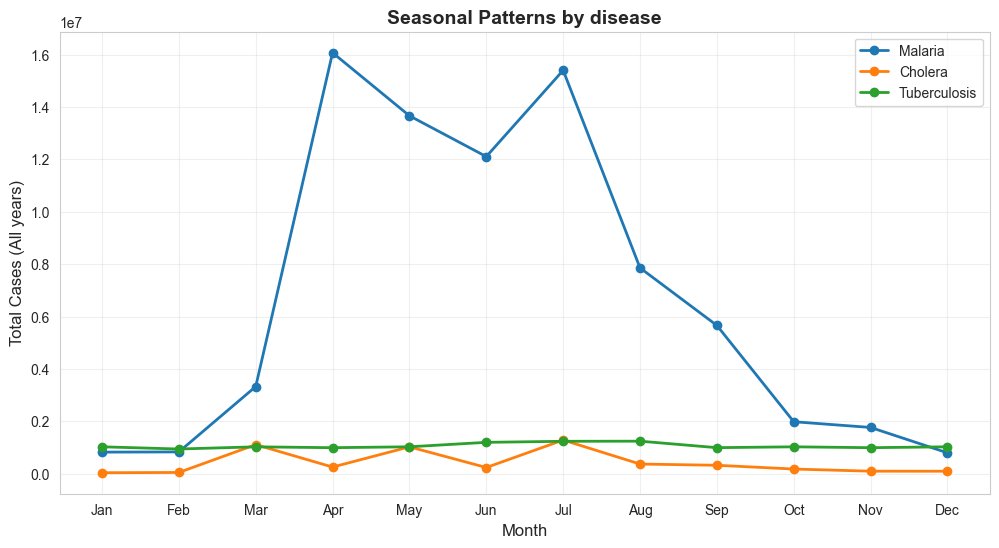

Malaria peaks in Apr
Cholera peaks in Jul
Tuberculosis peaks in Aug


In [9]:
reports_geo['month'] = reports_geo['report_date'].dt.month
seasonal = reports_geo.groupby(['month', 'disease'])['cases'].sum().reset_index()


fig, ax = plt.subplots(figsize=(12, 6))

countries = ['Kenya', 'Nigeria', 'South Africa']


for disease in diseases:
    disease_seasonal = seasonal[seasonal['disease'] == disease]
    ax.plot(disease_seasonal['month'], disease_seasonal['cases'], marker='o', linewidth=2, label=disease)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel(f'Total Cases (All years)', fontsize=12)
ax.set_title(f'Seasonal Patterns by disease', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig('../src/images/seasonal_patterns.png')  
plt.show()

for disease in diseases:
    disease_seasonal = seasonal[seasonal['disease'] == disease]
    peak_month = disease_seasonal.loc[disease_seasonal['cases'].idxmax(), 'month']
    month_names = ['', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug',
                   'Sep', 'Oct', 'Nov', 'Dec']
    print(f"{disease} peaks in {month_names[int(peak_month)]}")

#### Geographical hotspots

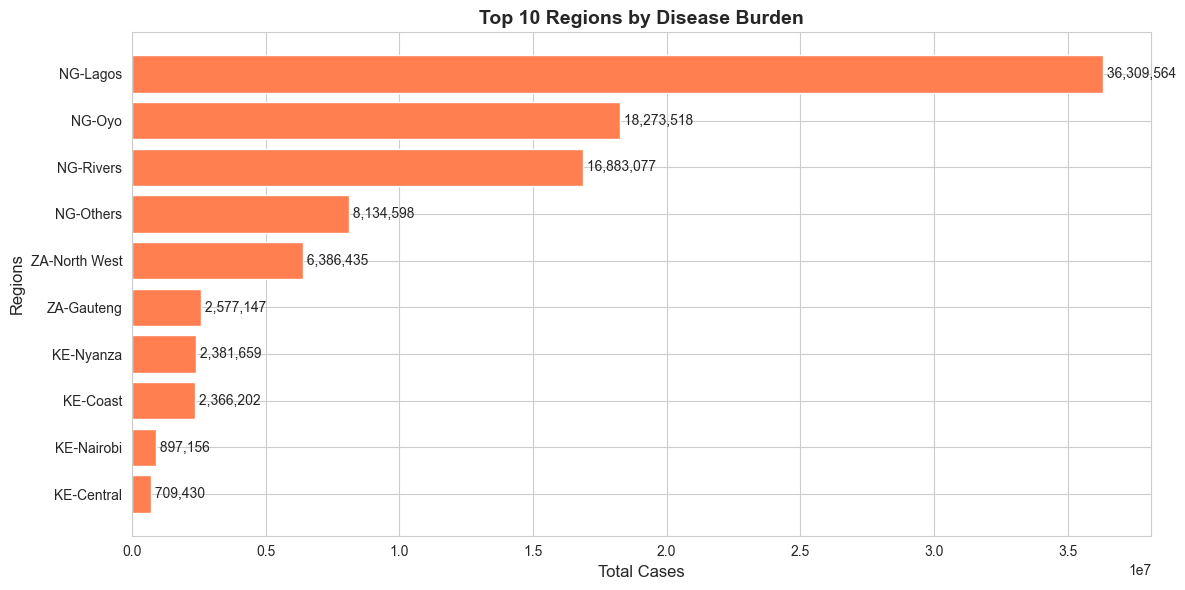

In [10]:
reports_region = reports.merge(geo[['geography_id', 'country_code', 'region_name', 'district_name']], on='geography_id')
region_cases = reports_region.groupby(['country_code', 'region_name'])['cases'].sum().reset_index().sort_values('cases', ascending=False)

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
top_regions = region_cases.head(10)
top_regions['label'] = top_regions['country_code'] + '-' + top_regions['region_name']

ax.barh(top_regions['label'], top_regions['cases'], color='coral')
ax.set_xlabel('Total Cases', fontsize=12)
ax.set_ylabel('Regions', fontsize=12)
ax.set_title('Top 10 Regions by Disease Burden', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for i, v in enumerate(top_regions['cases']):
    ax.text(v, i, f' {v:,.0f}', va='center')

plt.tight_layout()
plt.savefig('../src/images/top_regions_disease_burden.png')
plt.show()


#### Weather-Disease Correlation (Malaria)

Correlation: 0.361
Rainfall likely increases Malaria


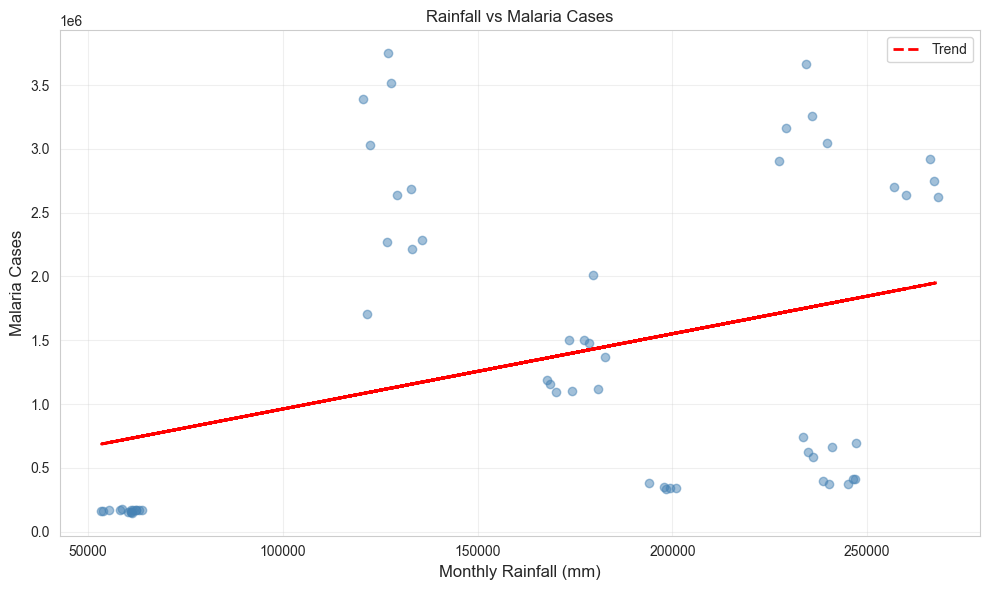

In [11]:
weather['year_month'] = weather['date'].dt.to_period('M')
monthly_rainfall = weather.groupby('year_month')['rainfall_mm'].sum().reset_index()

monthly_malaria = reports[reports['disease'] == 'Malaria'].groupby('year_month')['cases'].sum().reset_index()

weather_disease = monthly_rainfall.merge(monthly_malaria, on=['year_month'], how='inner')
weather_disease['year_month'] = weather_disease['year_month'].astype(str)

correlation = weather_disease['rainfall_mm'].corr(weather_disease['cases'])

print(f"Correlation: {correlation:.3f}")

if correlation > 0.3:
    print('Rainfall likely increases Malaria')
elif correlation > 0:
    print('Rainfall weakly affects Malaria cases')
else:
    print('Rainfall has to effect on Malaria cases')

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(weather_disease['rainfall_mm'], weather_disease['cases'], alpha=0.5, color='steelblue')
ax.set_xlabel('Monthly Rainfall (mm)', fontsize=12)
ax.set_ylabel("Malaria Cases", fontsize=12)
ax.set_title(f"Rainfall vs Malaria Cases")
z = np.polyfit(weather_disease['rainfall_mm'], weather_disease['cases'], 1)
p = np.poly1d(z)
ax.plot(weather_disease['rainfall_mm'], p(weather_disease['rainfall_mm']), "r--", linewidth=2, label='Trend')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../src/images/weather_malaria.png')
plt.show()

#### Insights Summary

In [12]:
top_disease = reports.groupby('disease')['cases'].sum().idxmax()
print(f"{top_disease} is the leading disease in terms of cases in during the 5 year period")
print("Cholera rates are generally minimal with spike in May, other months are consistent.")
print("Tuberculosis shows spike in June - August, otherwise the numbers are constant year-round.")

# Seasonality
reports['month'] = reports['report_date'].dt.month
malaria_seasonal = reports[reports['disease'] == 'Malaria'].groupby('month')['cases'].sum()
peak_month = malaria_seasonal.idxmax()
low_month = malaria_seasonal.idxmin()
month_names = {1:'January', 2:'February', 3:'March', 4:'April', 5:'May', 6:'June', 
               7:'July', 8:'August', 9:'September', 10:'October', 11:'November', 12:'December'}

print(f"Malaria peaks in {month_names[peak_month]} with {malaria_seasonal.max()} cases.")
print(f"Malaria cases are lowest in {month_names[low_month]} with {malaria_seasonal.min()} cases.")

# Weather correlation
print(f"Weather (rainfall) strongly affects Malaria cases with a correlation of {correlation:.2f}.")


Malaria is the leading disease in terms of cases in during the 5 year period
Cholera rates are generally minimal with spike in May, other months are consistent.
Tuberculosis shows spike in June - August, otherwise the numbers are constant year-round.
Malaria peaks in April with 16042488.0 cases.
Malaria cases are lowest in December with 794823.0 cases.
Weather (rainfall) strongly affects Malaria cases with a correlation of 0.36.


In [15]:
summary_stats = {
    'Metric':[
        'Total Reports',
        'Total Cases',
        'Total Deaths',
        'Fatality Rate (%)',
        'Date Range',
        'Countries',
        'Regions',
        'Facilities Reporting',
        'Malaria Cases',
        'Cholera Cases',
        'TB Cases'

    ],
    "Values": [
        f"{len(reports):,}",
        f"{reports['cases'].sum()}",
        f"{reports['deaths'].sum()}",
        f"{(reports['deaths'].sum() / reports['cases'].sum()) * 100:.2f}",
        f"{reports['report_date'].min().strftime('%Y-%m-%d')} to {reports['report_date'].max().strftime('%Y-%m-%d')}",
        f"{reports_geo['country_code'].nunique()}",
        f"{reports_region['region_name'].nunique()}",
        f"{reports['facility_id'].nunique()}",
        f"{reports[reports['disease'] == 'Malaria']['cases'].sum()}",
        f"{reports[reports['disease'] == 'Cholera']['cases'].sum()}",
        f"{reports[reports['disease'] == 'Tuberculosis']['cases'].sum()}",

    ]
}
